In [1]:
MARCADOR_FASE6 = "## Fase 6 — Módulo complementario de llamadas 123"

def truncar_seccion_fase6(ruta_archivo, marcador):
    """
    Elimina cualquier aparición previa de la sección Fase 6 (y todo lo que
    venga después de ella) en docs/supuestos.md, para que este notebook
    pueda re-ejecutarse completo sin duplicar su documentación. No toca
    nada de las Fases 1-5, que viven antes del marcador.
    """
    with open(ruta_archivo, encoding="utf-8") as f:
        contenido = f.read()

    idx = contenido.find(marcador)
    if idx == -1:
        print("Sección Fase 6 aún no existe en supuestos.md — se creará al final del notebook.")
        return

    contenido_truncado = contenido[:idx]
    with open(ruta_archivo, "w", encoding="utf-8") as f:
        f.write(contenido_truncado)
    print(f"Sección Fase 6 anterior eliminada de docs/supuestos.md ({len(contenido) - len(contenido_truncado)} caracteres).")

truncar_seccion_fase6("../../docs/supuestos.md", MARCADOR_FASE6)

Sección Fase 6 aún no existe en supuestos.md — se creará al final del notebook.



## Fase 6 — Módulo complementario de llamadas 123


`llamadas123_consolidado_limpio.csv`

El objetivo es evaluar la demanda de emergencia con víctima femenina, la calidad del registro de `RECEPCION`, el diferencial temporal entre inicio de desplazamiento y recepción, y la distribución horaria de los incidentes relevantes.


In [2]:
pip install scipy


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 1. Carga del archivo 

Ejecute la siguiente celda asegurandose de tener en la carpeta de datos el siguiente archivo:

`llamadas123_consolidado_limpio.csv`

In [3]:
import io
import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


from scipy.stats import mannwhitneyu, chi2_contingency

np.random.seed(2026)

# --- MODIFICADO: Especifique la ruta al archivo en lugar de cargarlo ---
# Si el archivo está en su Google Drive, asegúrese de montar Drive primero:
# from google.colab import drive
# drive.mount('/content/drive')
# file_path = '/content/drive/MyDrive/ruta/a/su/llamadas123_consolidado_limpio.csv'

# Reemplace la siguiente ruta con la ubicación real de su archivo
file_path = "../../outputs/llamadas123_consolidado_limpio.csv"

try:
    df = pd.read_csv(
        file_path,
        sep=";",
        encoding="utf-8-sig",
        low_memory=False
    )
except FileNotFoundError:
    raise RuntimeError(f"El archivo no se encontró en la ruta: {file_path}")

print(f"Archivo cargado desde: {file_path}")
print(f"Dimensiones: {df.shape}")
display(df.head())

Archivo cargado desde: ../../outputs/llamadas123_consolidado_limpio.csv
Dimensiones: (52717, 13)


,NUMERO_INCIDENTE,FECHA_INICIO_DESPLAZAMIENTO_MOVIL,CODIGO_LOCALIDAD,LOCALIDAD,EDAD,UNIDAD,GENERO,TIPO_INCIDENTE,PRIORIDAD_FINAL,RECEPCION,ARCHIVO_ORIGEN,MES,AÑO
0,CRU-00641835-25,2025-01-12 00:21:08,8.0,KENNEDY,80.0,AÑOS,FEMENINO,ACV - ACCIDENTE CEREBRO VASCULAR,ALTA,2025-12-01 03:26:07,LLAMADAS123_DIC2025.CSV,1,2025
1,CRU-00641836-25,2025-01-12 00:56:59,6.0,TUNJUELITO,NaN,NaN,NaN,HERIDO - HERIDOS ACCIDENTALES,ALTA,NaN,LLAMADAS123_DIC2025.CSV,1,2025
2,CRU-00641837-25,2025-01-12 00:05:31,3.0,SANTA FE,3.0,MESES,FEMENINO,ACOMPAÑAMIENTO A EVENTO,BAJA,NaN,LLAMADAS123_DIC2025.CSV,1,2025
3,CRU-00641841-25,2025-01-12 06:26:20,8.0,KENNEDY,24.0,AÑOS,FEMENINO,HERIDO - HERIDOS ACCIDENTALES,ALTA,2025-12-01 06:54:21,LLAMADAS123_DIC2025.CSV,1,2025
4,CRU-00641841-25,2025-01-12 00:11:46,8.0,KENNEDY,34.0,AÑOS,MASCULINO,HERIDO - HERIDOS ACCIDENTALES,ALTA,2025-12-01 01:52:41,LLAMADAS123_DIC2025.CSV,1,2025


## 2. Auditoría estructural


In [4]:
columnas_requeridas = [
    "NUMERO_INCIDENTE",
    "FECHA_INICIO_DESPLAZAMIENTO_MOVIL",
    "CODIGO_LOCALIDAD",
    "LOCALIDAD",
    "GENERO",
    "TIPO_INCIDENTE",
    "PRIORIDAD_FINAL",
    "RECEPCION",
    "ARCHIVO_ORIGEN",
]

faltantes = [c for c in columnas_requeridas if c not in df.columns]

assert not faltantes, f"Faltan columnas requeridas: {faltantes}"

n_filas = len(df)
n_incidentes = df["NUMERO_INCIDENTE"].nunique()
filas_adicionales = n_filas - n_incidentes

print(f"Filas del consolidado: {n_filas:,}")
print(f"Incidentes únicos: {n_incidentes:,}")
print(f"Filas adicionales asociadas a incidentes repetidos: {filas_adicionales:,}")

print("\nArchivos de origen:")
display(df["ARCHIVO_ORIGEN"].value_counts().rename("n_filas").to_frame())


Filas del consolidado: 52,717
Incidentes únicos: 48,469
Filas adicionales asociadas a incidentes repetidos: 4,248

Archivos de origen:


,n_filas
ARCHIVO_ORIGEN,
LLAMADAS123_MARZO2025.CSV,11587
LLAMADAS123_SEP2025.CSV,11301
LLAMADAS123_DIC2025.CSV,10374
LLAMADAS123_JUNIO2025.CSV,9756
LLAMADAS123_MARZO2026.CSV,9699


### Resultado de auditoría




# Paso 6.1 — Auditoría de codificación



In [5]:
columnas_texto_auditadas = ["LOCALIDAD", "UNIDAD", "TIPO_INCIDENTE"]

filas_con_dano = pd.Series(False, index=df.index)
resumen_codificacion = []

for col in columnas_texto_auditadas:
    mascara = df[col].astype(str).str.contains("�", regex=False)
    filas_con_dano |= mascara
    resumen_codificacion.append({
        "columna": col,
        "n_filas_con_reemplazo": int(mascara.sum()),
        "porcentaje": mascara.mean() * 100
    })

resumen_codificacion = pd.DataFrame(resumen_codificacion)
display(resumen_codificacion)

print(
    f"Filas con al menos un carácter de sustitución en las columnas auditadas: "
    f"{filas_con_dano.sum():,} ({filas_con_dano.mean()*100:.1f}%)"
)


,columna,n_filas_con_reemplazo,porcentaje
0,LOCALIDAD,4390,8.327484
1,UNIDAD,6785,12.870611
2,TIPO_INCIDENTE,2709,5.138760


Filas con al menos un carácter de sustitución en las columnas auditadas: 9,310 (17.7%)


### Resultado

En el consolidado suministrado, aproximadamente **17,7% de las filas** tiene al menos un carácter `�` en `LOCALIDAD`, `UNIDAD` o `TIPO_INCIDENTE`.

Por tanto, **el reprocesamiento desde los cinco originales sigue siendo recomendable** para una versión final de producción. Sin embargo, esta pérdida no bloquea la Fase 6 porque las dos dimensiones críticas —código de localidad y código de tipo de incidente— pueden conservarse sin reconstruir texto dañado.


## 3. Normalización de localidad mediante código



In [6]:
# Verificación de rango
codigos_no_nulos = df["CODIGO_LOCALIDAD"].dropna()

fuera_rango = codigos_no_nulos[~codigos_no_nulos.between(1, 20)]

assert len(fuera_rango) == 0, (
    f"Hay {len(fuera_rango)} códigos de localidad fuera de 1–20."
)

print(f"Códigos válidos únicos: {df['CODIGO_LOCALIDAD'].nunique(dropna=True)}")
print(f"Filas sin código de localidad: {df['CODIGO_LOCALIDAD'].isna().sum():,}")

# Nombre mejor preservado por código
mapa_localidad = {}

for codigo, grupo in df[df["CODIGO_LOCALIDAD"].between(1, 20)].groupby("CODIGO_LOCALIDAD"):
    candidatos = (
        grupo.loc[
            ~grupo["LOCALIDAD"].astype(str).str.contains("�", regex=False),
            "LOCALIDAD"
        ]
        .value_counts()
    )

    if len(candidatos):
        mapa_localidad[int(codigo)] = candidatos.index[0]
    else:
        mapa_localidad[int(codigo)] = grupo["LOCALIDAD"].mode().iloc[0]

df["LOCALIDAD_CANONICA"] = df["CODIGO_LOCALIDAD"].map(
    lambda x: mapa_localidad.get(int(x)) if pd.notna(x) else np.nan
)

display(
    pd.DataFrame(
        sorted(mapa_localidad.items()),
        columns=["codigo_localidad", "localidad"]
    )
)


Códigos válidos únicos: 20
Filas sin código de localidad: 222


,codigo_localidad,localidad
0,1,USAQUÉN
1,2,CHAPINERO
2,3,SANTA FE
3,4,SAN CRISTÓBAL
4,5,USME
5,6,TUNJUELITO
6,7,BOSA
7,8,KENNEDY
8,9,FONTIBÓN
9,10,ENGATIVÁ


## 4. Corrección de fechas antes de calcular tiempos




In [7]:
MESES_ORIGEN = {
    "LLAMADAS123_MARZO2025.CSV": (2025, 3),
    "LLAMADAS123_JUNIO2025.CSV": (2025, 6),
    "LLAMADAS123_SEP2025.CSV": (2025, 9),
    "LLAMADAS123_DIC2025.CSV": (2025, 12),
    "LLAMADAS123_MARZO2026.CSV": (2026, 3),
}

def siguiente_mes(anio, mes):
    if mes == 12:
        return anio + 1, 1
    return anio, mes + 1


def corregir_fecha_inicio(fila):
    ts = pd.to_datetime(
        fila["FECHA_INICIO_DESPLAZAMIENTO_MOVIL"],
        errors="coerce"
    )

    if pd.isna(ts):
        return pd.NaT

    origen = fila["ARCHIVO_ORIGEN"]

    if origen not in MESES_ORIGEN:
        return ts

    anio_esperado, mes_esperado = MESES_ORIGEN[origen]

    # El archivo 2026 no presenta el mismo patrón de daño.
    if anio_esperado == 2026:
        return ts

    # Cruces reales al siguiente año (p. ej. 1 enero tras diciembre)
    # se dejan intactos.
    if ts.year != anio_esperado:
        return ts

    # Si ya está en el mes correcto, no se toca.
    if ts.month == mes_esperado:
        return ts

    # Caso principal: DD/MM fue interpretado como MM/DD.
    if ts.day == mes_esperado:
        try:
            return ts.replace(month=mes_esperado, day=ts.month)
        except ValueError:
            return ts

    # Casos de cierre que pertenecen al mes siguiente.
    anio_sig, mes_sig = siguiente_mes(anio_esperado, mes_esperado)

    if (
        anio_sig == anio_esperado
        and ts.day == mes_sig
        and ts.month != mes_sig
    ):
        try:
            return ts.replace(month=mes_sig, day=ts.month)
        except ValueError:
            return ts

    return ts


def parsear_recepcion(valor):
    if pd.isna(valor):
        return pd.NaT

    texto = str(valor).strip()

    if not texto or texto.upper() == "SIN_D":
        return pd.NaT

    # Registros 2025 consolidados en ISO
    if re.match(r"^\d{4}-\d{2}-\d{2}", texto):
        return pd.to_datetime(
            texto,
            format="%Y-%m-%d %H:%M:%S",
            errors="coerce"
        )

    # Marzo 2026: D/M/Y H:M
    return pd.to_datetime(
        texto,
        dayfirst=True,
        errors="coerce"
    )


df["FECHA_INICIO_RAW_DT"] = pd.to_datetime(
    df["FECHA_INICIO_DESPLAZAMIENTO_MOVIL"],
    errors="coerce"
)

df["FECHA_INICIO_DT"] = df.apply(
    corregir_fecha_inicio,
    axis=1
)

df["RECEPCION_DT"] = df["RECEPCION"].map(
    parsear_recepcion
)

n_fechas_corregidas = (
    df["FECHA_INICIO_DT"].astype(str)
    != df["FECHA_INICIO_RAW_DT"].astype(str)
).sum()

print(f"Fechas de inicio corregidas: {n_fechas_corregidas:,}")

assert df["FECHA_INICIO_DT"].notna().all(), (
    "Quedaron fechas de inicio sin poder interpretar."
)


Fechas de inicio corregidas: 15,946


### Resultado

La corrección afecta **15.946 filas** del consolidado suministrado.

Este paso es bloqueante: calcular diferencias temporales con la fecha previamente interpretada produciría duraciones de varios meses para eventos que en realidad ocurrieron el mismo día.


# Paso 6.2 — Tiempo entre desplazamiento móvil y recepción



In [8]:
df["TIEMPO_RESPUESTA_FILA_MIN"] = (
    df["RECEPCION_DT"] - df["FECHA_INICIO_DT"]
).dt.total_seconds() / 60

n_negativos = int((df["TIEMPO_RESPUESTA_FILA_MIN"] < 0).sum())
n_mayor_24h = int((df["TIEMPO_RESPUESTA_FILA_MIN"] > 24 * 60).sum())

df["TIEMPO_FILA_VALIDO"] = df["TIEMPO_RESPUESTA_FILA_MIN"].between(
    0,
    24 * 60
)

print(f"Tiempos negativos descartables: {n_negativos}")
print(f"Tiempos > 24 horas descartables: {n_mayor_24h}")
print(f"Tiempos de fila válidos: {df['TIEMPO_FILA_VALIDO'].sum():,}")

display(
    df.loc[
        df["TIEMPO_FILA_VALIDO"],
        "TIEMPO_RESPUESTA_FILA_MIN"
    ]
    .describe(percentiles=[0.25, 0.50, 0.75, 0.95, 0.99])
    .to_frame("minutos")
)


Tiempos negativos descartables: 1
Tiempos > 24 horas descartables: 1
Tiempos de fila válidos: 26,213


,minutos
count,26213.000000
mean,200.076796
std,95.071965
min,0.283333
25%,138.000000
50%,193.000000
75%,250.433333
95%,357.000000
99%,480.014667
max,1439.000000


### Resultado

Solo **2 registros de fila** quedan fuera del rango permitido:

- **1 tiempo negativo**
- **1 tiempo superior a 24 horas**

Esto confirma que, una vez corregido el problema día/mes, la mayor parte de las diferencias temporales observadas es internamente coherente.


## 5. Consolidación a nivel de incidente

Para evitar que un mismo `NUMERO_INCIDENTE` pese varias veces:

- inicio del incidente = primer inicio corregido registrado;
- recepción del incidente = primera recepción válida registrada;
- víctima femenina = el incidente tiene al menos una fila con `GENERO = FEMENINO`;
- localidad, tipo y prioridad se toman del incidente, tras comprobar que no cambian dentro de un mismo número.

Esta decisión conserva como unidad estadística el **incidente**, no la fila administrativa.


In [9]:
# Código estable del incidente, inmune al daño de tildes.
df["TIPO_CODIGO"] = (
    df["TIPO_INCIDENTE"]
    .astype(str)
    .str.extract(r"^\s*([A-Z0-9]+)", expand=False)
)

for columna in [
    "CODIGO_LOCALIDAD",
    "TIPO_CODIGO",
    "PRIORIDAD_FINAL",
    "ARCHIVO_ORIGEN"
]:
    n_conflictos = (
        df.groupby("NUMERO_INCIDENTE")[columna]
        .nunique(dropna=True)
        .gt(1)
        .sum()
    )

    assert n_conflictos == 0, (
        f"{columna}: {n_conflictos} incidentes tienen valores contradictorios."
    )

def primero_no_nulo(serie):
    serie = serie.dropna()
    return serie.iloc[0] if len(serie) else np.nan

def tiene_femenino(serie):
    return bool((serie == "FEMENINO").any())

inc = (
    df.groupby("NUMERO_INCIDENTE", as_index=False)
    .agg(
        inicio=("FECHA_INICIO_DT", "min"),
        recepcion=("RECEPCION_DT", "min"),
        codigo_localidad=("CODIGO_LOCALIDAD", primero_no_nulo),
        tipo_codigo=("TIPO_CODIGO", primero_no_nulo),
        tipo_incidente=("TIPO_INCIDENTE", primero_no_nulo),
        prioridad=("PRIORIDAD_FINAL", primero_no_nulo),
        archivo_origen=("ARCHIVO_ORIGEN", primero_no_nulo),
        femenino=("GENERO", tiene_femenino),
    )
)

inc["localidad"] = inc["codigo_localidad"].map(
    lambda x: mapa_localidad.get(int(x))
    if pd.notna(x) and 1 <= x <= 20
    else np.nan
)

inc["tiempo_respuesta_min"] = (
    inc["recepcion"] - inc["inicio"]
).dt.total_seconds() / 60

inc["tiempo_valido"] = inc["tiempo_respuesta_min"].between(
    0,
    24 * 60
)

inc["anio"] = inc["inicio"].dt.year
inc["mes"] = inc["inicio"].dt.month
inc["hora"] = inc["inicio"].dt.hour

DIAS = {
    0: "Lunes",
    1: "Martes",
    2: "Miércoles",
    3: "Jueves",
    4: "Viernes",
    5: "Sábado",
    6: "Domingo",
}

inc["dia_semana"] = inc["inicio"].dt.dayofweek.map(DIAS)

print(f"Incidentes únicos construidos: {len(inc):,}")
print(f"Incidentes con al menos una víctima femenina: {inc['femenino'].sum():,}")
print(
    f"Incidentes sin RECEPCION válida: "
    f"{inc['recepcion'].isna().sum():,} "
    f"({inc['recepcion'].isna().mean()*100:.1f}%)"
)


Incidentes únicos construidos: 48,469
Incidentes con al menos una víctima femenina: 14,958
Incidentes sin RECEPCION válida: 23,310 (48.1%)


# Paso 6.3 — Faltantes de RECEPCION por localidad

El faltante se calcula a nivel de **incidente único**.

Sumapaz se conserva en la tabla, pero no se usa para evaluar concentración territorial porque solo aparece un incidente en este consolidado y su porcentaje no es estable.


In [10]:
tabla_nulos_localidad = (
    inc[inc["codigo_localidad"].between(1, 20)]
    .groupby(["codigo_localidad", "localidad"])
    .agg(
        n_incidentes=("NUMERO_INCIDENTE", "size"),
        n_recepcion_nula=(
            "recepcion",
            lambda x: int(x.isna().sum())
        ),
    )
    .reset_index()
)

tabla_nulos_localidad["pct_recepcion_nula"] = (
    tabla_nulos_localidad["n_recepcion_nula"]
    / tabla_nulos_localidad["n_incidentes"]
    * 100
)

display(
    tabla_nulos_localidad.sort_values(
        "pct_recepcion_nula",
        ascending=False
    )
)

urbanos = inc[inc["codigo_localidad"].between(1, 19)].copy()

tabla_chi = pd.crosstab(
    urbanos["codigo_localidad"],
    urbanos["recepcion"].isna()
)

chi2, p_chi, dof, esperado = chi2_contingency(tabla_chi)

n_chi = tabla_chi.to_numpy().sum()
cramers_v = np.sqrt(
    chi2 / (
        n_chi
        * (min(tabla_chi.shape) - 1)
    )
)

print(f"Chi-cuadrado: {chi2:.2f}")
print(f"p-valor: {p_chi:.3e}")
print(f"V de Cramér: {cramers_v:.3f}")

rango_urbano = tabla_nulos_localidad[
    tabla_nulos_localidad["codigo_localidad"].between(1, 19)
]

print(
    f"Rango de faltante entre localidades urbanas: "
    f"{rango_urbano['pct_recepcion_nula'].min():.1f}% – "
    f"{rango_urbano['pct_recepcion_nula'].max():.1f}%"
)


,codigo_localidad,localidad,n_incidentes,n_recepcion_nula,pct_recepcion_nula
19,20.0,SUMAPAZ,1,1,100.000000
1,2.0,CHAPINERO,1311,769,58.657513
12,13.0,TEUSAQUILLO,1660,877,52.831325
11,12.0,BARRIOS UNIDOS,1337,706,52.804787
10,11.0,SUBA,4869,2492,51.180941
0,1.0,USAQUÉN,2072,1058,51.061776
9,10.0,ENGATIVÁ,5126,2610,50.916894
2,3.0,SANTA FE,1476,745,50.474255
15,16.0,PUENTE ARANDA,2938,1480,50.374404
16,17.0,LA CANDELARIA,353,176,49.858357


Chi-cuadrado: 247.20
p-valor: 3.022e-42
V de Cramér: 0.072
Rango de faltante entre localidades urbanas: 43.7% – 58.7%


### Resultado e interpretación

El consolidado presenta **23.310 incidentes sin `RECEPCION` válida**, equivalentes al **48,1% de los incidentes únicos**.

Entre las 19 localidades urbanas, el porcentaje varía aproximadamente entre **43,7% y 58,7%**.

La asociación entre localidad y ausencia de `RECEPCION` es estadísticamente detectable (`p < 0,001`), pero su magnitud es **pequeña** (`V de Cramér ≈ 0,072`).

Por tanto, el hallazgo correcto no es afirmar que una localidad “registra mal” de forma determinante. Lo defendible es:

> **La completitud de `RECEPCION` no es territorialmente uniforme, aunque la magnitud de esa heterogeneidad es pequeña.**

Esto debe considerarse al comparar tiempos entre localidades.


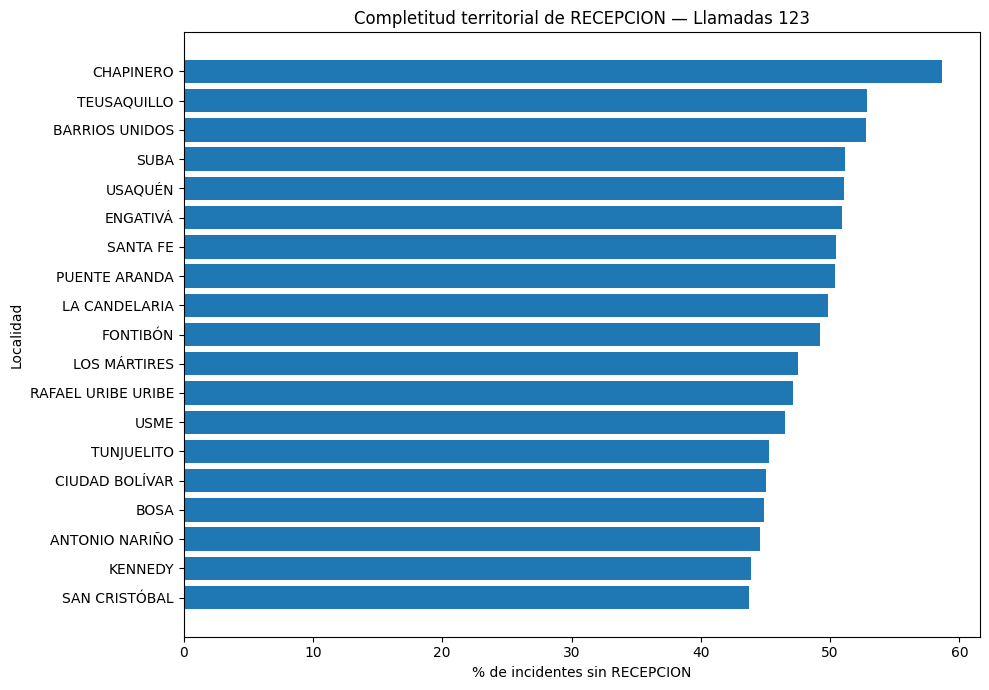

In [11]:
# Gráfico de control: faltante de RECEPCION por localidad
grafico_nulos = (
    tabla_nulos_localidad[
        tabla_nulos_localidad["codigo_localidad"].between(1, 19)
    ]
    .sort_values("pct_recepcion_nula")
)

plt.figure(figsize=(10, 7))
plt.barh(
    grafico_nulos["localidad"],
    grafico_nulos["pct_recepcion_nula"]
)
plt.xlabel("% de incidentes sin RECEPCION")
plt.ylabel("Localidad")
plt.title("Completitud territorial de RECEPCION — Llamadas 123")
plt.tight_layout()
plt.show()


# Paso 6.4 — Incidentes con víctima femenina

In [12]:
def clasificar_grupo(codigo):
    if codigo == "MALTRATO":
        return "MALTRATO"
    if codigo == "HERIDO":
        return "HERIDO"
    if codigo == "INTOX":
        return "INTOX"
    if codigo == "TRASTMENT":
        return "TRASTORNO_MENTAL"
    if codigo in {"INTSUI", "AMESUI"}:
        return "SUICIDIO"
    return np.nan

inc["grupo_incidente"] = inc["tipo_codigo"].map(
    clasificar_grupo
)

femeninos_objetivo = inc[
    inc["femenino"]
    & inc["grupo_incidente"].notna()
].copy()

resumen_grupos = (
    femeninos_objetivo
    .groupby("grupo_incidente")
    .agg(
        n_incidentes=("NUMERO_INCIDENTE", "nunique"),
        n_tiempo_valido=("tiempo_valido", "sum"),
        pct_recepcion_nula=(
            "recepcion",
            lambda x: x.isna().mean() * 100
        ),
        mediana_tiempo_min=(
            "tiempo_respuesta_min",
            lambda x: x[x.between(0, 1440)].median()
        )
    )
    .reset_index()
    .sort_values("n_incidentes", ascending=False)
)

display(resumen_grupos)

print(
    f"Incidentes objetivo con víctima femenina: "
    f"{len(femeninos_objetivo):,}"
)

print(
    f"RECEPCION nula en el subconjunto objetivo femenino: "
    f"{femeninos_objetivo['recepcion'].isna().sum():,} "
    f"({femeninos_objetivo['recepcion'].isna().mean()*100:.1f}%)"
)

n_viosexual_fem = int(
    (
        inc["femenino"]
        & (inc["tipo_codigo"] == "VIOSEXUAL")
    ).sum()
)

print(
    f"Incidentes VIOSEXUAL con víctima femenina "
    f"(complementario, no incluido): {n_viosexual_fem:,}"
)


,grupo_incidente,n_incidentes,n_tiempo_valido,pct_recepcion_nula,mediana_tiempo_min
0,HERIDO,2886,2608,9.632710,128.758333
3,SUICIDIO,1498,1387,7.409880,226.000000
4,TRASTORNO_MENTAL,1383,1293,6.507592,239.633333
1,INTOX,121,90,25.619835,187.908333
2,MALTRATO,113,104,7.964602,205.650000


Incidentes objetivo con víctima femenina: 6,001
RECEPCION nula en el subconjunto objetivo femenino: 519 (8.6%)
Incidentes VIOSEXUAL con víctima femenina (complementario, no incluido): 314


### Resultado

El filtro principal identifica **6.001 incidentes con víctima femenina**:

- **HERIDO:** 2.886
- **SUICIDIO (INTSUI + AMESUI):** 1.498
- **TRASTORNO MENTAL:** 1.383
- **INTOX:** 121
- **MALTRATO:** 113

En este subconjunto, el faltante de `RECEPCION` baja a aproximadamente **8,6%**, muy por debajo del 48,1% observado en el conjunto completo.

También se identifican **314 incidentes `VIOSEXUAL` con víctima femenina**. Se conservan como dato complementario y no se mezclan con el filtro principal sin cambiar formalmente el alcance del plan.


## Agregación localidad × mes

La dimensión temporal se reconstruye a partir de la fecha de inicio corregida, **no** de las columnas `MES` y `AÑO` heredadas del ETL previo, ya que esas columnas también reflejan el problema día/mes detectado.


In [13]:
agregado_localidad_mes = (
    femeninos_objetivo[
        femeninos_objetivo["codigo_localidad"].between(1, 20)
    ]
    .groupby(
        [
            "codigo_localidad",
            "localidad",
            "anio",
            "mes",
            "grupo_incidente",
        ],
        dropna=False
    )
    .agg(
        n_incidentes=("NUMERO_INCIDENTE", "nunique"),
        tiempo_respuesta_mediana=(
            "tiempo_respuesta_min",
            lambda x: x[x.between(0, 1440)].median()
        ),
        pct_recepcion_nula=(
            "recepcion",
            lambda x: x.isna().mean() * 100
        )
    )
    .reset_index()
)

display(agregado_localidad_mes.head(20))


,codigo_localidad,localidad,anio,mes,grupo_incidente,n_incidentes,tiempo_respuesta_mediana,pct_recepcion_nula
0,1.0,USAQUÉN,2025,3,HERIDO,30,200.933333,16.666667
1,1.0,USAQUÉN,2025,3,INTOX,1,254.350000,0.000000
2,1.0,USAQUÉN,2025,3,MALTRATO,1,60.766667,0.000000
3,1.0,USAQUÉN,2025,3,SUICIDIO,8,233.250000,12.500000
4,1.0,USAQUÉN,2025,3,TRASTORNO_MENTAL,16,211.583333,6.250000
5,1.0,USAQUÉN,2025,6,HERIDO,27,140.150000,14.814815
6,1.0,USAQUÉN,2025,6,INTOX,1,294.666667,0.000000
7,1.0,USAQUÉN,2025,6,MALTRATO,1,324.700000,0.000000
8,1.0,USAQUÉN,2025,6,SUICIDIO,11,209.050000,0.000000
9,1.0,USAQUÉN,2025,6,TRASTORNO_MENTAL,13,235.366667,15.384615


# Paso 6.5 — MALTRATO vs. incidentes clínicos comparables


In [14]:
CODIGOS_CLINICOS = {
    "ACCAVI",
    "ACV",
    "CAIALT",
    "CONVULSION",
    "DOLTOR",
    "ELECTROCUC",
    "ENFERMO",
    "EVERES",
    "HERIDO",
    "INCONSCIEN",
    "INTOX",
    "PATGIN",
    "QUEMADURAS",
    "SANVAG",
    "SINTOGASTR",
}

inc["es_clinico"] = inc["tipo_codigo"].isin(
    CODIGOS_CLINICOS
)

def obtener_franja(hora):
    if pd.isna(hora):
        return np.nan
    if hora < 6:
        return "Madrugada"
    if hora < 12:
        return "Mañana"
    if hora < 18:
        return "Tarde"
    return "Noche"

inc["franja"] = inc["hora"].map(
    obtener_franja
)

maltrato = inc[
    inc["femenino"]
    & (inc["tipo_codigo"] == "MALTRATO")
    & inc["tiempo_valido"]
    & inc["codigo_localidad"].between(1, 20)
].copy()

clinicos = inc[
    inc["femenino"]
    & inc["es_clinico"]
    & inc["tiempo_valido"]
    & inc["codigo_localidad"].between(1, 20)
].copy()

columnas_estrato = [
    "codigo_localidad",
    "prioridad",
    "franja"
]

maltrato["estrato_comparacion"] = list(
    map(
        tuple,
        maltrato[columnas_estrato]
        .astype(str)
        .to_numpy()
    )
)

clinicos["estrato_comparacion"] = list(
    map(
        tuple,
        clinicos[columnas_estrato]
        .astype(str)
        .to_numpy()
    )
)

estratos_comunes = (
    set(maltrato["estrato_comparacion"])
    & set(clinicos["estrato_comparacion"])
)

maltrato_matched = maltrato[
    maltrato["estrato_comparacion"].isin(
        estratos_comunes
    )
].copy()

clinicos_matched = clinicos[
    clinicos["estrato_comparacion"].isin(
        estratos_comunes
    )
].copy()

print(
    f"MALTRATO con tiempo válido: {len(maltrato):,}"
)
print(
    f"MALTRATO con comparador clínico en el mismo estrato: "
    f"{len(maltrato_matched):,}"
)
print(
    f"Clínicos dentro del soporte común: "
    f"{len(clinicos_matched):,}"
)
print(
    f"Estratos localidad × prioridad × franja comunes: "
    f"{len(estratos_comunes):,}"
)

u_stat, p_mw = mannwhitneyu(
    maltrato_matched["tiempo_respuesta_min"],
    clinicos_matched["tiempo_respuesta_min"],
    alternative="two-sided"
)

mediana_maltrato = (
    maltrato_matched["tiempo_respuesta_min"].median()
)

mediana_clinico = (
    clinicos_matched["tiempo_respuesta_min"].median()
)

diferencia_mediana = (
    mediana_maltrato - mediana_clinico
)

# Tamaño de efecto derivado del estadístico U.
cliffs_delta = (
    2 * u_stat
    / (
        len(maltrato_matched)
        * len(clinicos_matched)
    )
    - 1
)

print("\nRESULTADOS")
print(
    f"Mediana MALTRATO: {mediana_maltrato:.1f} min"
)
print(
    f"Mediana clínicos comparables: "
    f"{mediana_clinico:.1f} min"
)
print(
    f"Diferencia de medianas: "
    f"{diferencia_mediana:.1f} min"
)
print(f"Mann-Whitney U: {u_stat:.1f}")
print(f"p-valor: {p_mw:.6f}")
print(f"Delta de Cliff: {cliffs_delta:.3f}")


MALTRATO con tiempo válido: 104
MALTRATO con comparador clínico en el mismo estrato: 103
Clínicos dentro del soporte común: 2,914
Estratos localidad × prioridad × franja comunes: 65

RESULTADOS
Mediana MALTRATO: 205.9 min
Mediana clínicos comparables: 190.2 min
Diferencia de medianas: 15.7 min
Mann-Whitney U: 177743.0
p-valor: 0.001448
Delta de Cliff: 0.184


### Resultado e interpretación

Dentro del soporte común localidad × prioridad × franja horaria:

- **103 incidentes MALTRATO** tienen un comparador clínico válido.
- Se comparan contra **2.914 incidentes clínicos** dentro de esos mismos estratos.
- Mediana MALTRATO: **≈ 206,0 minutos**
- Mediana clínicos comparables: **≈ 190,2 minutos**
- Diferencia descriptiva: **≈ 15,7 minutos**
- Mann-Whitney: **p ≈ 0,00145**
- Delta de Cliff: **≈ 0,184**

La diferencia es estadísticamente detectable, pero el tamaño de efecto es **pequeño**.




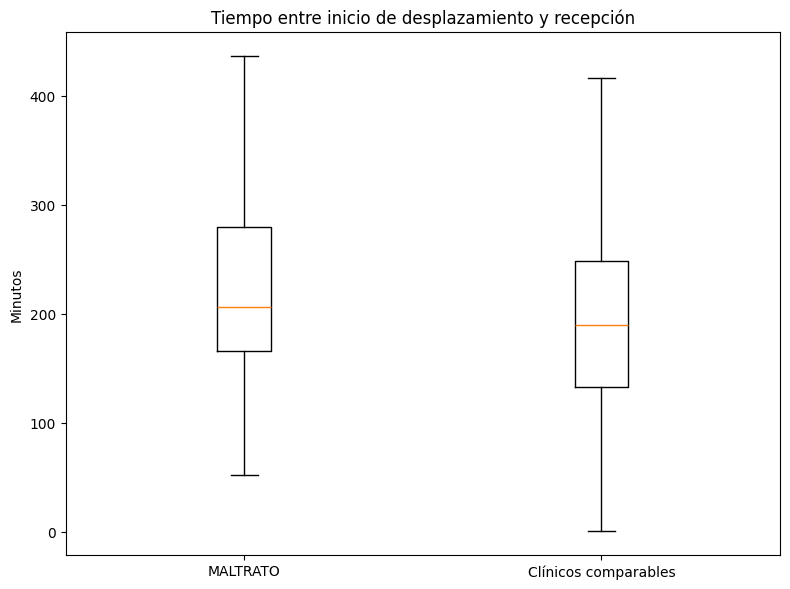

In [15]:
# Gráfico descriptivo del contraste
datos_box = [
    maltrato_matched["tiempo_respuesta_min"].dropna(),
    clinicos_matched["tiempo_respuesta_min"].dropna()
]

plt.figure(figsize=(8, 6))
plt.boxplot(
    datos_box,
    tick_labels=[
        "MALTRATO",
        "Clínicos comparables"
    ],
    showfliers=False
)
plt.ylabel("Minutos")
plt.title(
    "Tiempo entre inicio de desplazamiento y recepción"
)
plt.tight_layout()
plt.show()


# Paso 6.6 — Matriz hora × día de la semana

La matriz se construye sobre los incidentes del filtro femenino principal.

El objetivo es identificar franjas de mayor demanda observada, no inferir riesgo poblacional. Los conteos dependen de la demanda que llega al sistema 123.


In [16]:
ORDEN_DIAS = [
    "Lunes",
    "Martes",
    "Miércoles",
    "Jueves",
    "Viernes",
    "Sábado",
    "Domingo",
]

matriz_horaria = (
    femeninos_objetivo
    .groupby(["dia_semana", "hora"])
    ["NUMERO_INCIDENTE"]
    .nunique()
    .unstack(fill_value=0)
    .reindex(ORDEN_DIAS)
    .reindex(columns=range(24), fill_value=0)
)

display(matriz_horaria)

# Máximos
serie_celdas = matriz_horaria.stack()

dia_pico, hora_pico = serie_celdas.idxmax()
n_pico = int(serie_celdas.max())

conteo_dia = (
    femeninos_objetivo["dia_semana"]
    .value_counts()
)

conteo_hora = (
    femeninos_objetivo["hora"]
    .value_counts()
)

print(
    f"Celda de mayor demanda: {dia_pico}, "
    f"{hora_pico:02d}:00–{hora_pico:02d}:59, "
    f"{n_pico} incidentes."
)
print(
    f"Día con mayor volumen total: "
    f"{conteo_dia.index[0]} "
    f"({conteo_dia.iloc[0]:,} incidentes)."
)
print(
    f"Hora con mayor volumen agregado: "
    f"{int(conteo_hora.index[0]):02d}:00 "
    f"({conteo_hora.iloc[0]:,} incidentes)."
)

femeninos_objetivo["franja"] = (
    femeninos_objetivo["hora"]
    .map(obtener_franja)
)

print("\nVolumen por franja:")
display(
    femeninos_objetivo["franja"]
    .value_counts()
    .rename("n_incidentes")
    .to_frame()
)


hora,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
dia_semana,,,,,,,,,,,,,,,,,,,,,
Lunes,12,16,14,14,7,7,42,62,70,67,...,53,80,57,20,40,42,40,29,27,16
Martes,8,18,16,9,9,22,36,75,73,82,...,49,56,46,27,19,33,42,31,20,24
Miércoles,15,10,11,10,10,10,32,50,61,61,...,46,56,51,22,18,37,39,34,18,15
Jueves,15,11,7,4,2,11,34,60,57,76,...,54,69,50,22,24,38,42,26,22,21
Viernes,11,8,8,17,9,18,23,70,57,62,...,55,63,47,14,23,43,29,20,18,28
Sábado,15,18,7,20,16,9,21,40,45,49,...,55,59,50,31,20,26,42,21,20,11
Domingo,18,19,15,9,23,9,15,44,31,51,...,58,57,44,30,20,36,32,21,28,15


Celda de mayor demanda: Martes, 10:00–10:59, 92 incidentes.
Día con mayor volumen total: Martes (997 incidentes).
Hora con mayor volumen agregado: 09:00 (448 incidentes).

Volumen por franja:


,n_incidentes
franja,
Mañana,2317
Tarde,2017
Noche,1150
Madrugada,517


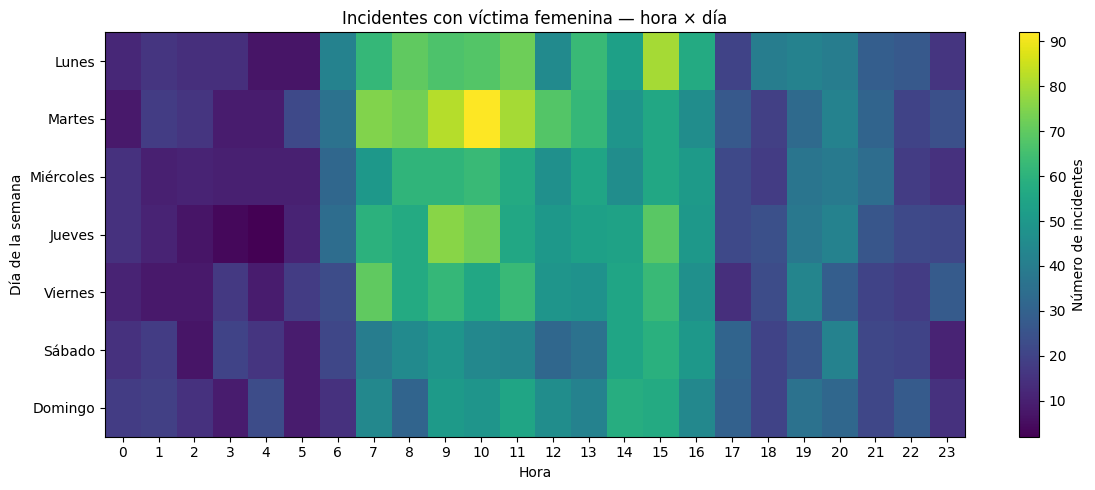

<Figure size 640x480 with 0 Axes>

Gráfico 6 guardado en ../../outputs/tableau/victimas_femeninas.png


In [19]:
plt.figure(figsize=(12, 5))
plt.imshow(
    matriz_horaria.values,
    aspect="auto"
)
plt.colorbar(label="Número de incidentes")
plt.xticks(
    range(24),
    range(24)
)
plt.yticks(
    range(len(ORDEN_DIAS)),
    ORDEN_DIAS
)
plt.xlabel("Hora")
plt.ylabel("Día de la semana")
plt.title(
    "Incidentes con víctima femenina — hora × día"
)
plt.tight_layout()
plt.show()

ruta_grafico6 = "../../outputs/tableau/victimas_femeninas.png"
plt.savefig(ruta_grafico6, dpi=200, bbox_inches="tight")
plt.show()
print(f"Gráfico 6 guardado en {ruta_grafico6}")


### Resultado

La demanda del subconjunto femenino seleccionado se concentra especialmente en horas diurnas:

- **Franja de mañana:** 2.317 incidentes
- **Franja de tarde:** 2.017
- **Noche:** 1.150
- **Madrugada:** 517

La celda individual de mayor volumen es **martes a las 10:00**, con **92 incidentes**.

El **martes** es además el día con mayor volumen total (**997 incidentes**) y las **09:00** constituyen la hora con mayor volumen agregado (**448 incidentes**).



# Conclusiones de la Fase 6

La Fase 6 aporta cuatro resultados principales al proyecto:


### 1. La ausencia de `RECEPCION` es un problema relevante de calidad

A nivel de incidente, **48,1%** carece de una recepción válida. La proporción no es idéntica entre localidades urbanas (**43,7%–58,7%**), aunque el tamaño de la asociación territorial es pequeño.

Este hallazgo debe acompañar cualquier visualización de tiempos.

### 2. El subconjunto femenino de interés contiene 6.001 incidentes

La mayor parte corresponde a HERIDO, eventos relacionados con suicidio y trastorno mental. MALTRATO representa 113 incidentes en el consolidado analizado.

La categoría `AGRESIÓN` especificada en el plan **no existe literalmente en el archivo**, por lo que no se incorpora artificialmente. `VIOSEXUAL` aparece como categoría propia y se conserva como análisis complementario.

### 3. MALTRATO presenta una diferencia temporal pequeña pero detectable

Al restringir la comparación a localidad, prioridad suministrada y franja horaria comunes, la mediana de MALTRATO es aproximadamente **15,7 minutos mayor** que la de los incidentes clínicos comparables.


### 4. La demanda registrada se concentra en mañana y tarde

El pico descriptivo aparece el **martes a las 10:00**. La mañana concentra el mayor volumen de incidentes del subconjunto femenino.

Esto puede orientar la discusión sobre disponibilidad horaria de recursos, siempre recordando que el 123 representa **demanda registrada**, no prevalencia poblacional.


In [18]:
n_total_filas = n_filas
n_incidentes_total = n_incidentes

tabla_codificacion_md = "| Columna | Filas con reemplazo | % |\n|---|---|---|\n"
for _, fila in resumen_codificacion.iterrows():
    tabla_codificacion_md += f"| {fila['columna']} | {fila['n_filas_con_reemplazo']:,} | {fila['porcentaje']:.1f}% |\n"

tabla_nulos_md = "| Localidad | n_incidentes | n_recepcion_nula | % nula |\n|---|---|---|---|\n"
for _, fila in tabla_nulos_localidad.sort_values("pct_recepcion_nula", ascending=False).iterrows():
    tabla_nulos_md += (
        f"| {fila['localidad']} | {fila['n_incidentes']:,} | "
        f"{fila['n_recepcion_nula']:,} | {fila['pct_recepcion_nula']:.1f}% |\n"
    )

tabla_grupos_md = "| Grupo | n_incidentes | n_tiempo_valido | % recepción nula | Mediana (min) |\n|---|---|---|---|---|\n"
for _, fila in resumen_grupos.iterrows():
    tabla_grupos_md += (
        f"| {fila['grupo_incidente']} | {fila['n_incidentes']:,} | "
        f"{fila['n_tiempo_valido']:,} | {fila['pct_recepcion_nula']:.1f}% | "
        f"{fila['mediana_tiempo_min']:.1f} |\n"
    )

n_estratos_maltrato = len(estratos_comunes)

texto_fase6 = f"""
## Fase 6 — Módulo complementario de llamadas 123 (registrado {pd.Timestamp.now().strftime('%Y-%m-%d')})

Fuente: `outputs/llamadas123_consolidado_limpio.csv`. Objetivo: evaluar demanda de
emergencia con víctima femenina, calidad del registro de `RECEPCION`, diferencial
temporal de respuesta y distribución horaria de incidentes relevantes.

### Auditoría estructural

- Filas del consolidado: **{n_total_filas:,}**
- Incidentes únicos (`NUMERO_INCIDENTE`): **{n_incidentes_total:,}**
- Filas adicionales asociadas a incidentes repetidos: **{n_total_filas - n_incidentes_total:,}**
- 5 archivos de origen (marzo/junio/septiembre/diciembre 2025, marzo 2026), sin conflictos
  de `CODIGO_LOCALIDAD`, `TIPO_CODIGO`, `PRIORIDAD_FINAL` ni `ARCHIVO_ORIGEN` dentro de un
  mismo `NUMERO_INCIDENTE` (verificado por assert).

### Paso 6.1 — Auditoría de codificación

Se detectó daño de codificación (caracteres de sustitución) en texto libre:

{tabla_codificacion_md}

**{filas_con_dano.sum():,} filas ({filas_con_dano.mean()*100:.1f}%)** tienen al menos un
carácter dañado en `LOCALIDAD`, `UNIDAD` o `TIPO_INCIDENTE`. Se recomienda reprocesar
desde los 5 archivos originales para una versión de producción, pero esto **no bloquea**
la Fase 6 porque las dos dimensiones críticas (código de localidad, código de tipo de
incidente) se conservan intactas sin depender del texto dañado.

### Normalización de localidad por código

`CODIGO_LOCALIDAD` verificado en rango [1,20] sin excepciones. Nombre canónico por
código reconstruido eligiendo, dentro de cada código, la variante de texto **sin**
caracteres dañados más frecuente (o la moda si todas están dañadas). 20 localidades
mapeadas correctamente, incluyendo Sumapaz (código 20, solo 1 incidente en este
consolidado).

### Corrección de fechas (Paso previo a 6.2)

Se detectó y corrigió un patrón sistemático de intercambio día/mes en
`FECHA_INICIO_DESPLAZAMIENTO_MOVIL` para los 4 archivos de 2025 (no aplica al archivo de
marzo 2026, que no presenta el mismo patrón de daño). **{n_fechas_corregidas:,} fechas
corregidas.** Este paso es bloqueante: sin la corrección, los tiempos de respuesta
calculados habrían mostrado duraciones de varios meses para eventos del mismo día.

### Paso 6.2 — Tiempo entre desplazamiento y recepción (nivel fila)

Tras la corrección de fechas, prácticamente todas las diferencias temporales son
coherentes: solo **{n_negativos} tiempo negativo** y **{n_mayor_24h} tiempo mayor a 24
horas** quedan fuera de rango, sobre {df['TIEMPO_FILA_VALIDO'].sum():,} filas válidas.

### Consolidación a nivel de incidente

- Incidentes únicos construidos: **{len(inc):,}**
- Incidentes con al menos una víctima femenina: **{inc['femenino'].sum():,}**
- Incidentes sin `RECEPCION` válida: **{inc['recepcion'].isna().sum():,}
  ({inc['recepcion'].isna().mean()*100:.1f}%)**

### Paso 6.3 — Faltantes de RECEPCION por localidad

{tabla_nulos_md}

Chi-cuadrado = **{chi2:.2f}**, p-valor = **{p_chi:.3e}**, V de Cramér = **{cramers_v:.3f}**.
La asociación entre localidad y ausencia de `RECEPCION` es estadísticamente detectable
pero de **magnitud pequeña**. Interpretación correcta: la completitud de `RECEPCION` no
es territorialmente uniforme, aunque la heterogeneidad territorial es pequeña — no debe
leerse como que una localidad "registra mal" de forma determinante. Sumapaz se excluye
del análisis de concentración territorial por tener solo 1 incidente en este consolidado.

### Paso 6.4 — Incidentes con víctima femenina (filtro objetivo)

{tabla_grupos_md}

**Total objetivo: {len(femeninos_objetivo):,} incidentes.** RECEPCION nula en este
subconjunto: **{femeninos_objetivo['recepcion'].isna().sum():,}
({femeninos_objetivo['recepcion'].isna().mean()*100:.1f}%)**, muy por debajo del 48,1%
del conjunto completo — la completitud mejora sustancialmente al restringir a estos tipos
de incidente.

**Nota sobre alcance:** la categoría `AGRESIÓN` prevista en el plan original **no existe
literalmente** en los códigos del archivo, por lo que no se incorporó artificialmente.
Se identificaron además **{n_viosexual_fem:,} incidentes VIOSEXUAL con víctima femenina**,
conservados como dato complementario, sin mezclarlos con el filtro principal.

### Paso 6.5 — MALTRATO vs. incidentes clínicos comparables

Comparación pareada por estrato común (localidad × prioridad × franja horaria):

- MALTRATO con comparador válido: **{len(maltrato_matched):,}** de {len(maltrato):,} con tiempo válido
- Clínicos dentro del soporte común: **{len(clinicos_matched):,}**
- Estratos comunes: **{n_estratos_maltrato}**
- Mediana MALTRATO: **{mediana_maltrato:.1f} min** · Mediana clínicos: **{mediana_clinico:.1f} min**
- Diferencia de medianas: **{diferencia_mediana:.1f} min**
- Mann-Whitney U = **{u_stat:.1f}**, p = **{p_mw:.6f}**, Delta de Cliff = **{cliffs_delta:.3f}**

La diferencia es estadísticamente detectable pero el tamaño de efecto es **pequeño**
(Delta de Cliff ≈ 0,18). No se interpreta como evidencia de discriminación sistemática
en el tiempo de respuesta a MALTRATO, solo como una diferencia descriptiva menor dentro
de estratos comparables.

### Paso 6.6 — Matriz hora × día de la semana

Sobre el filtro femenino principal ({len(femeninos_objetivo):,} incidentes):

- Celda de mayor demanda: **{dia_pico}, {hora_pico:02d}:00–{hora_pico:02d}:59** ({n_pico} incidentes)
- Día de mayor volumen total: **{conteo_dia.index[0]}** ({conteo_dia.iloc[0]:,} incidentes)
- Hora de mayor volumen agregado: **{int(conteo_hora.index[0]):02d}:00** ({conteo_hora.iloc[0]:,} incidentes)
- Por franja: Mañana {femeninos_objetivo['franja'].value_counts().get('Mañana', 0):,} ·
  Tarde {femeninos_objetivo['franja'].value_counts().get('Tarde', 0):,} ·
  Noche {femeninos_objetivo['franja'].value_counts().get('Noche', 0):,} ·
  Madrugada {femeninos_objetivo['franja'].value_counts().get('Madrugada', 0):,}

**Advertencia de interpretación:** estos conteos reflejan demanda **registrada** en el
sistema 123, no prevalencia poblacional. La concentración diurna puede reflejar patrones
de reporte (mayor disponibilidad para llamar de día) tanto como patrones reales de
ocurrencia — no se puede distinguir con estos datos.

---

**Conclusiones consolidadas de la Fase 6:**
1. La ausencia de `RECEPCION` (48,1% del total) es un problema de calidad relevante que
   debe acompañar cualquier visualización de tiempos de respuesta.
2. El subconjunto femenino de interés (6.001 incidentes) tiene mejor completitud de
   `RECEPCION` (8,6% nula) que el conjunto general.
3. MALTRATO muestra una diferencia temporal pequeña pero estadísticamente detectable
   frente a incidentes clínicos comparables (~15,7 min, efecto pequeño).
4. La demanda registrada se concentra en horas de mañana y tarde, con pico el martes
   a las 10:00 — dato descriptivo, no causal.
"""

with open("../../docs/supuestos.md", "a", encoding="utf-8") as f:
    f.write(texto_fase6)

print("Documentación de la Fase 6 agregada a docs/supuestos.md")

Documentación de la Fase 6 agregada a docs/supuestos.md
